In [1]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
pip install torchvision

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.2 MB 2.9 MB/s eta 0:00:02
   ----------------- ---------------------- 1.8/4.2 MB 3.3 MB/s eta 0:00:01
   ------------------------- -------------- 2.6/4.2 MB 3.4 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 3.6 MB/s  0:00:01
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/122.1 MB 4.9 MB/s eta 0:00:25
    --------------------------------------- 1.6/122.1 MB 5.0 MB/s eta 0:00:24
    --------------------------------------- 2.6/122.1 MB 4.4 MB/s eta 0:00:28
   - -------------------------------------- 3.4/122.1 MB 4.4 MB/s eta 0:00:27
   - -------------------------------------- 4.5/122.1 MB 4.4 MB/s eta 0:00:27
   - -------------------

In [24]:
import os

import tqdm


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Dataset

In [21]:
directory = "C:\\Users\\User\\Documents\\ДЗ\\NA_Fish_Dataset"

In [22]:
labels = os.listdir(directory)

In [13]:
labels

['Black Sea Sprat',
 'Gilt Head Bream',
 'Horse Mackerel',
 'Red Mullet',
 'Red Sea Bream',
 'Sea Bass',
 'Shrimp',
 'Striped Red Mullet',
 'Trout']

In [14]:
image_paths = []
target = []
for fish_type in labels:
    for file in os.listdir(os.path.join(directory, fish_type)):
        image_paths.append(os.path.join(directory, fish_type, file))
        target.append(fish_type)

In [15]:
df = pd.DataFrame({'img' : image_paths, 'target' : target})
df.head()

,img,target
0,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
1,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
2,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
3,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
4,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat


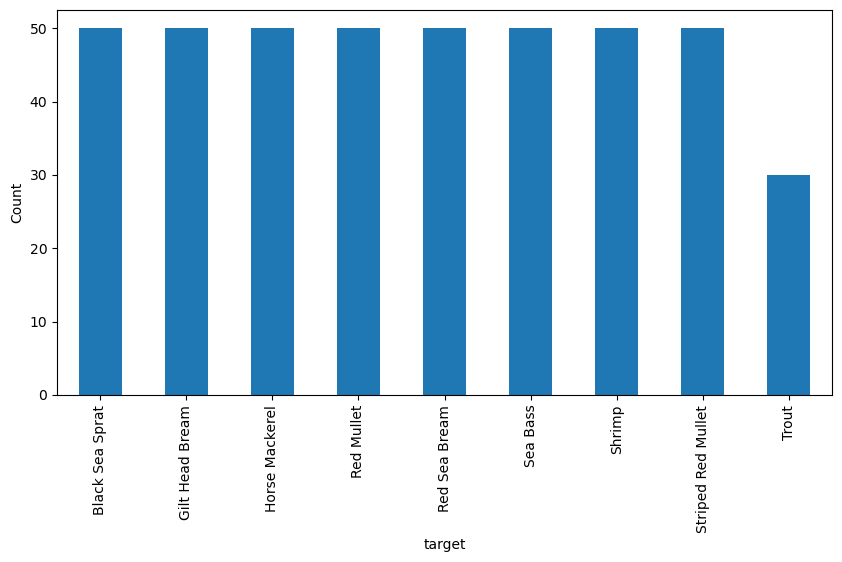

In [16]:
plt.figure(figsize=(10, 5))
df['target'].value_counts().plot(kind='bar')
plt.ylabel('Count')
plt.show()

In [25]:
train_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(
        brightness=0.2,   
        contrast=0.2,  
        saturation=0.15,  
        hue=0.05        
    ),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

val_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [28]:
indices_to_drop = df[~df['target'].isin(['Black Sea Sprat', 'Gilt Head Bream'])].index
df = df.drop(indices_to_drop)

In [29]:
df

,img,target
0,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
1,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
2,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
3,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
4,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Bla...,Black Sea Sprat
...,...,...
95,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
96,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
97,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream
98,C:\Users\User\Documents\ДЗ\NA_Fish_Dataset\Gil...,Gilt Head Bream


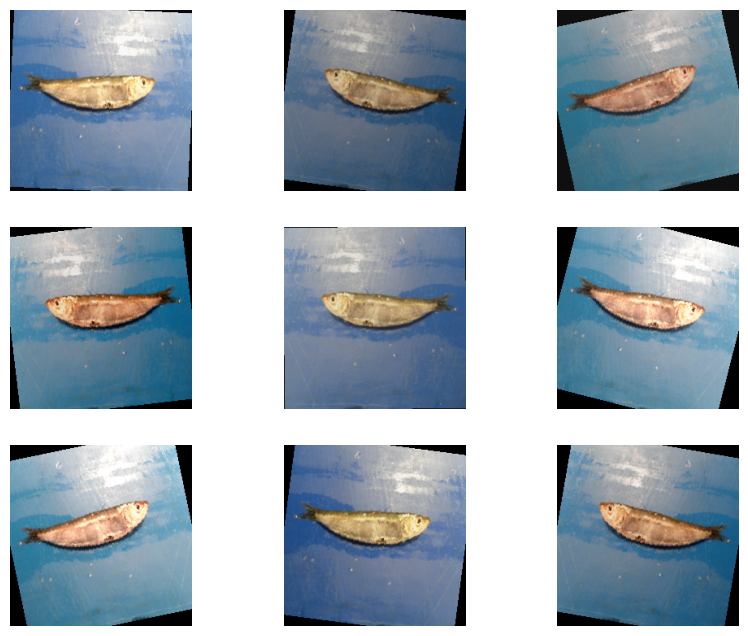

In [30]:
image = Image.open(df['img'].iloc[0])

sample_size = 9
fig, ax = plt.subplots(3, 3, figsize=(10, 8))
ax = ax.flatten()

for i in range(sample_size):
    augmented = train_transform(image)
    ax[i].imshow(augmented.permute(1, 2, 0))
    ax[i].axis('off')

plt.axis('off')
plt.show()